## Visualize the experiment with grid view

### Environment Setup

In [2]:
# Import package
import os
import sys
import numpy as np

from glob import glob
from typing import Tuple
from pathlib import Path

from matplotlib import pyplot as plt

sys.path.append("/Users/joseph/Desktop/NTU Course/114-2/Data Assimilation/Project/Code/src")
import verification as ver # type: ignore
import l96_model as l96    # type: ignore
import integrate as integ  # type: ignore

# Path setup
root_path: Path = Path("/Users/joseph/Desktop/NTU Course/114-2/Data Assimilation/Project")
file_path: Path = root_path / "Files"
fig_path : Path = root_path / "Figure"

plt.style.use(root_path / "Code" / "src" / "stylelist.mplstyle")


### Load data

In [3]:
# Load nature run
nature_run: dict[str, np.ndarray] = dict(
    np.load(file_path / "traj" / "nature_run.npz")
)

# Load free run
free_run: dict[str, np.ndarray] = dict(
    np.load(file_path / "traj" / "free_run.npz")
)

# Load optimal interpolation on X
OI_run: dict[str, np.ndarray] = dict(
    np.load(file_path / "traj" / "OI" / "NMC" / "on_X.npz")
)

# Load 3D-Var on X
n3D_run: dict[str, np.ndarray] = dict(
    np.load(file_path / "traj" / "3DVar" / "NMC" / "on_X.npz")
)

# Load incremental 3D-Var on X
i3D_run: dict[str, np.ndarray] = dict(
    np.load(file_path / "traj" / "incremental_3DVar" / "NMC" / "on_X.npz")
)

# Load simulated observation
obs_run: dict[str, np.ndarray] = dict(
    np.load(file_path / "simulated_observations.npz")
)

### Calculate background field

In [4]:
params: l96.L96Params = l96.L96Params(h=0.9)

state_199 = (OI_run["X"][1999], 
             OI_run["Y"][1999], 
             OI_run["Z"][1999])

background_200 = integ.rk4_step(state=state_199, params=params, dt=0.01, tendency_fn=l96.compute_tendencies)

X_b = background_200[0]

X_a = OI_run["X"][2000]

### Visualie the grid of specific time

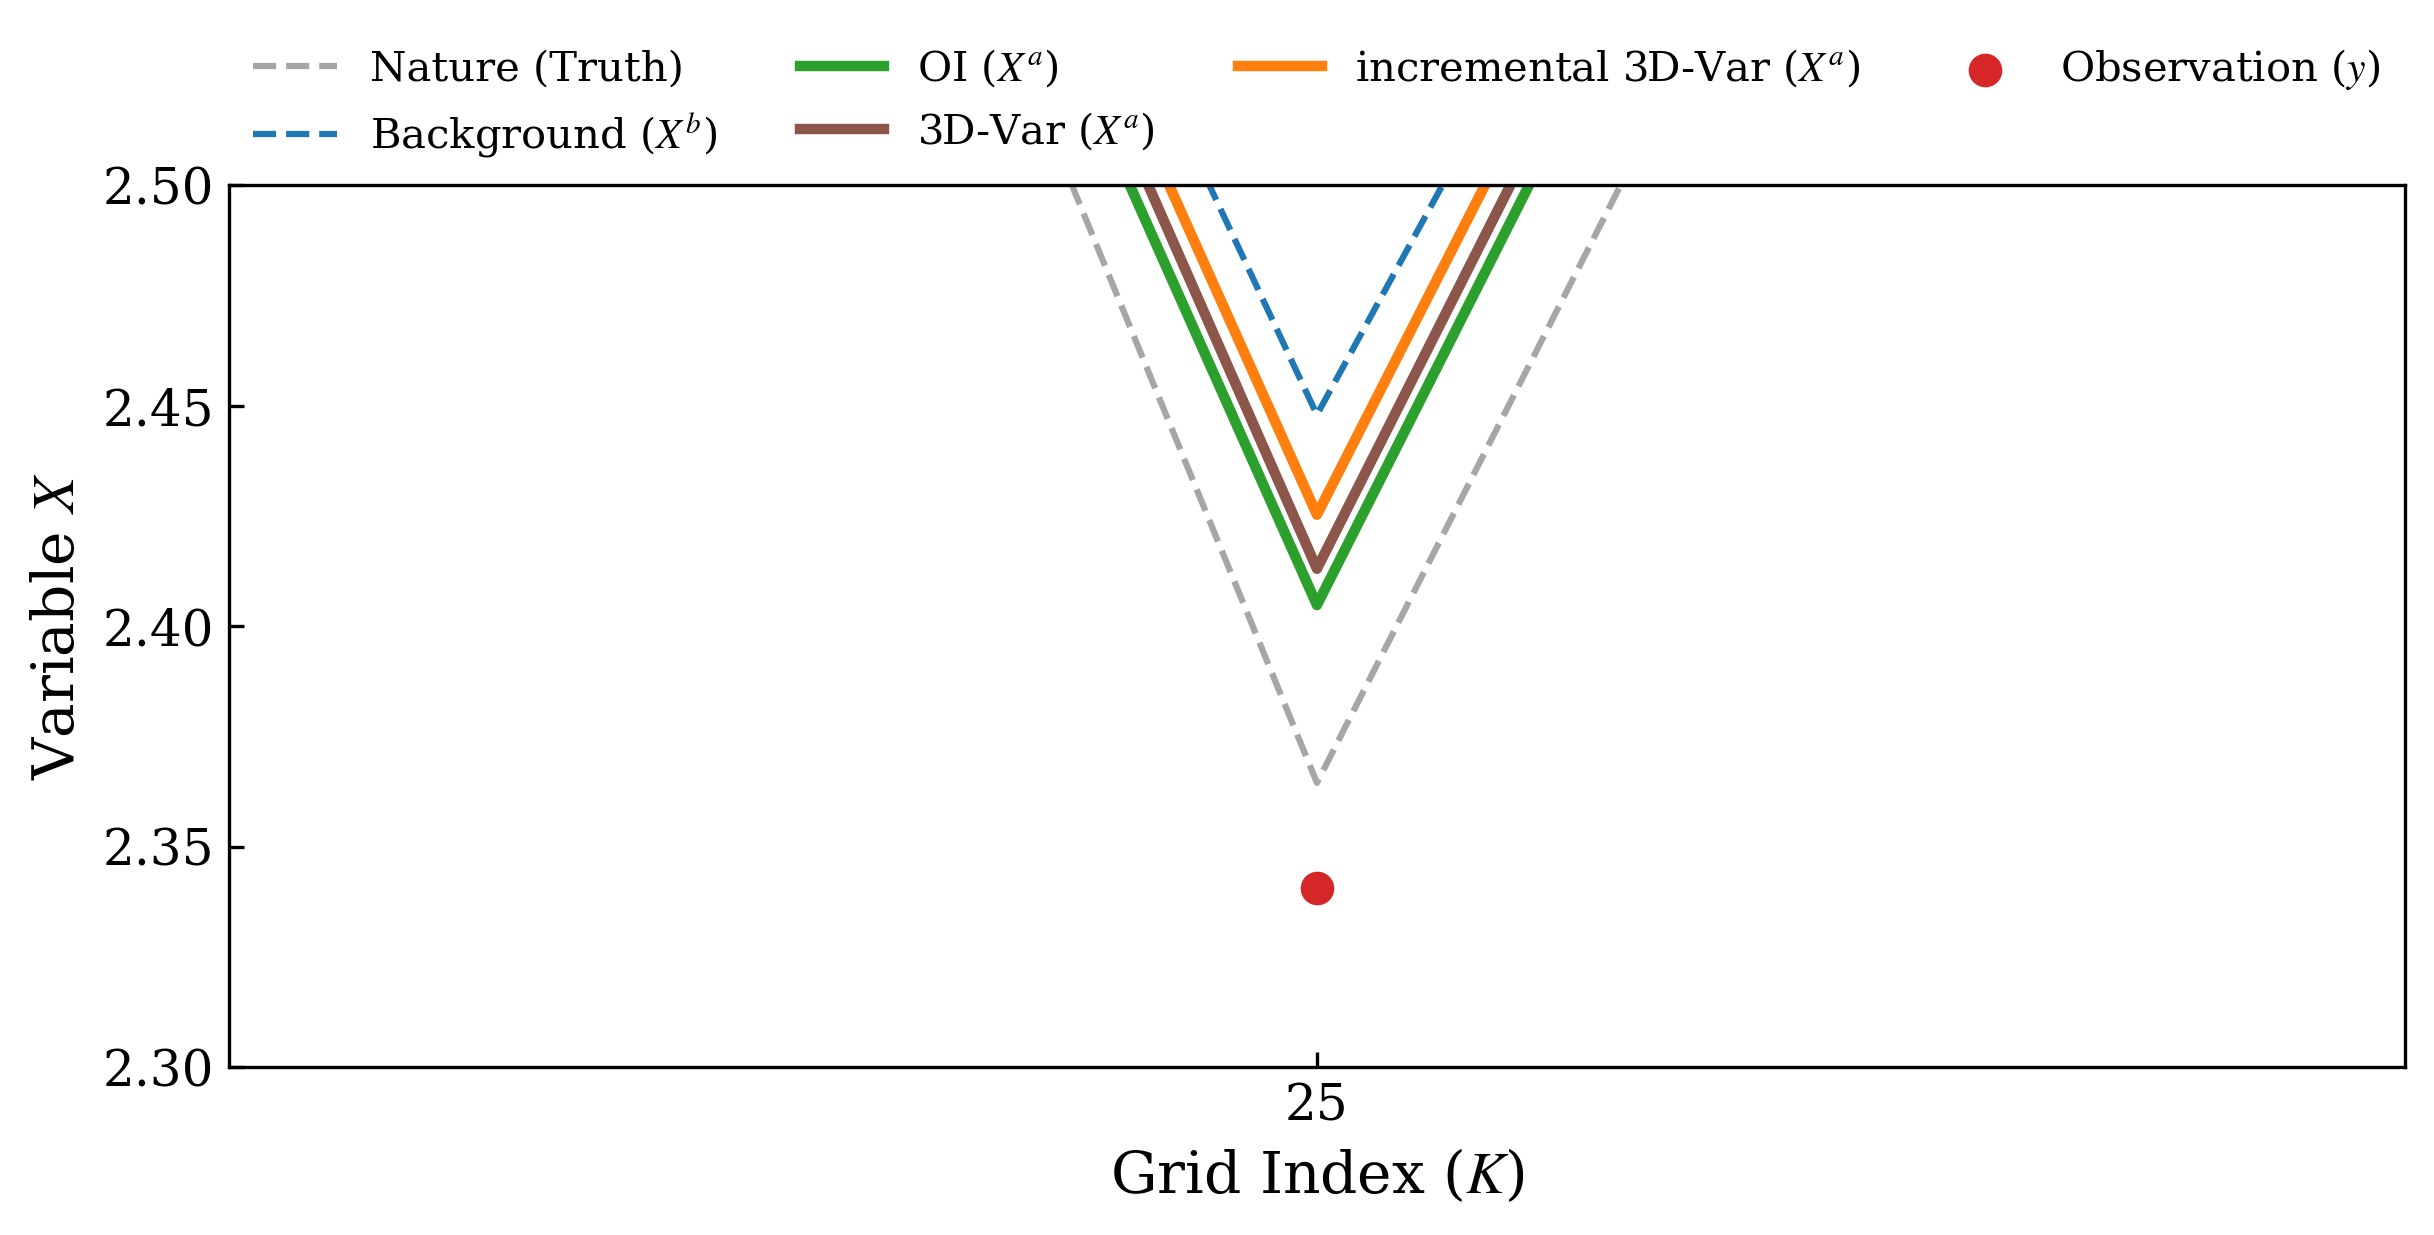

In [5]:
# time index
t_idx: int = 2000

fig, ax = plt.subplots(1, 1, figsize=(8, 4)) # 稍微寬扁一點，波形較好看

# 1. Nature (真值) - 作為參考答案，用灰色虛線
ax.plot(
    np.arange(40), nature_run["X"][t_idx].flatten(),
    linestyle="--", label="Nature (Truth)", color="gray", alpha=0.7
)

# 2. Background (背景場) - 尚未同化的預估波形，用藍色虛線
ax.plot(
    np.arange(40), X_b.flatten(),
    linestyle="--", label=r"Background ($X^b$)", color="tab:blue"
)

# 3. Analysis (分析場) - 修正後的最終波形，用綠色粗實線
ax.plot(
    np.arange(40), X_a.flatten(),
    linestyle="-", linewidth=2.5, label=r"OI ($X^a$)", color="tab:green"
)

ax.plot(
    np.arange(40), n3D_run["X"][t_idx].flatten(),
    linestyle="-", linewidth=2.5, label=r"3D-Var ($X^a$)", color="tab:brown"
)

ax.plot(
    np.arange(40), i3D_run["X"][t_idx].flatten(),
    linestyle="-", linewidth=2.5, label=r"incremental 3D-Var ($X^a$)", color="tab:orange"
)

# 4. Observation (觀測點) - 只有觀測資料是離散的，用紅色圓點 (scatter)
ax.scatter(
    np.arange(40), obs_run["X"][np.where(obs_run["X_idx"]==t_idx)[0][0]],
    marker="o", s=50, label="Observation ($y$)", color="tab:red", zorder=5
)

# 視角放寬到 10 個網格，剛好能看清楚一個波形的修正
ax.set_xlim(24, 26)
ax.set_ylim(2.3, 2.5)

# 把 Y 軸的限制拿掉，讓 Matplotlib 自動適應波形的振幅
# (如果你原本的 1.5 到 2.2 是為了配合極度放大的視角，現在放寬到 20~30 就會被截斷)

ax.set_xticks([25])

ax.set_xlabel(r"Grid Index ($K$)")
ax.set_ylabel(r"Variable $X$")
# ax.set_title(f"Spatial Profile at DA Step (t = {t_idx*0.01})")

# 把 Legend 放到圖的上方，比較不會擋住波浪
ax.legend(ncol=4, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.20))

plt.savefig(fig_path / "grid" / f"X_t={t_idx*0.01}.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

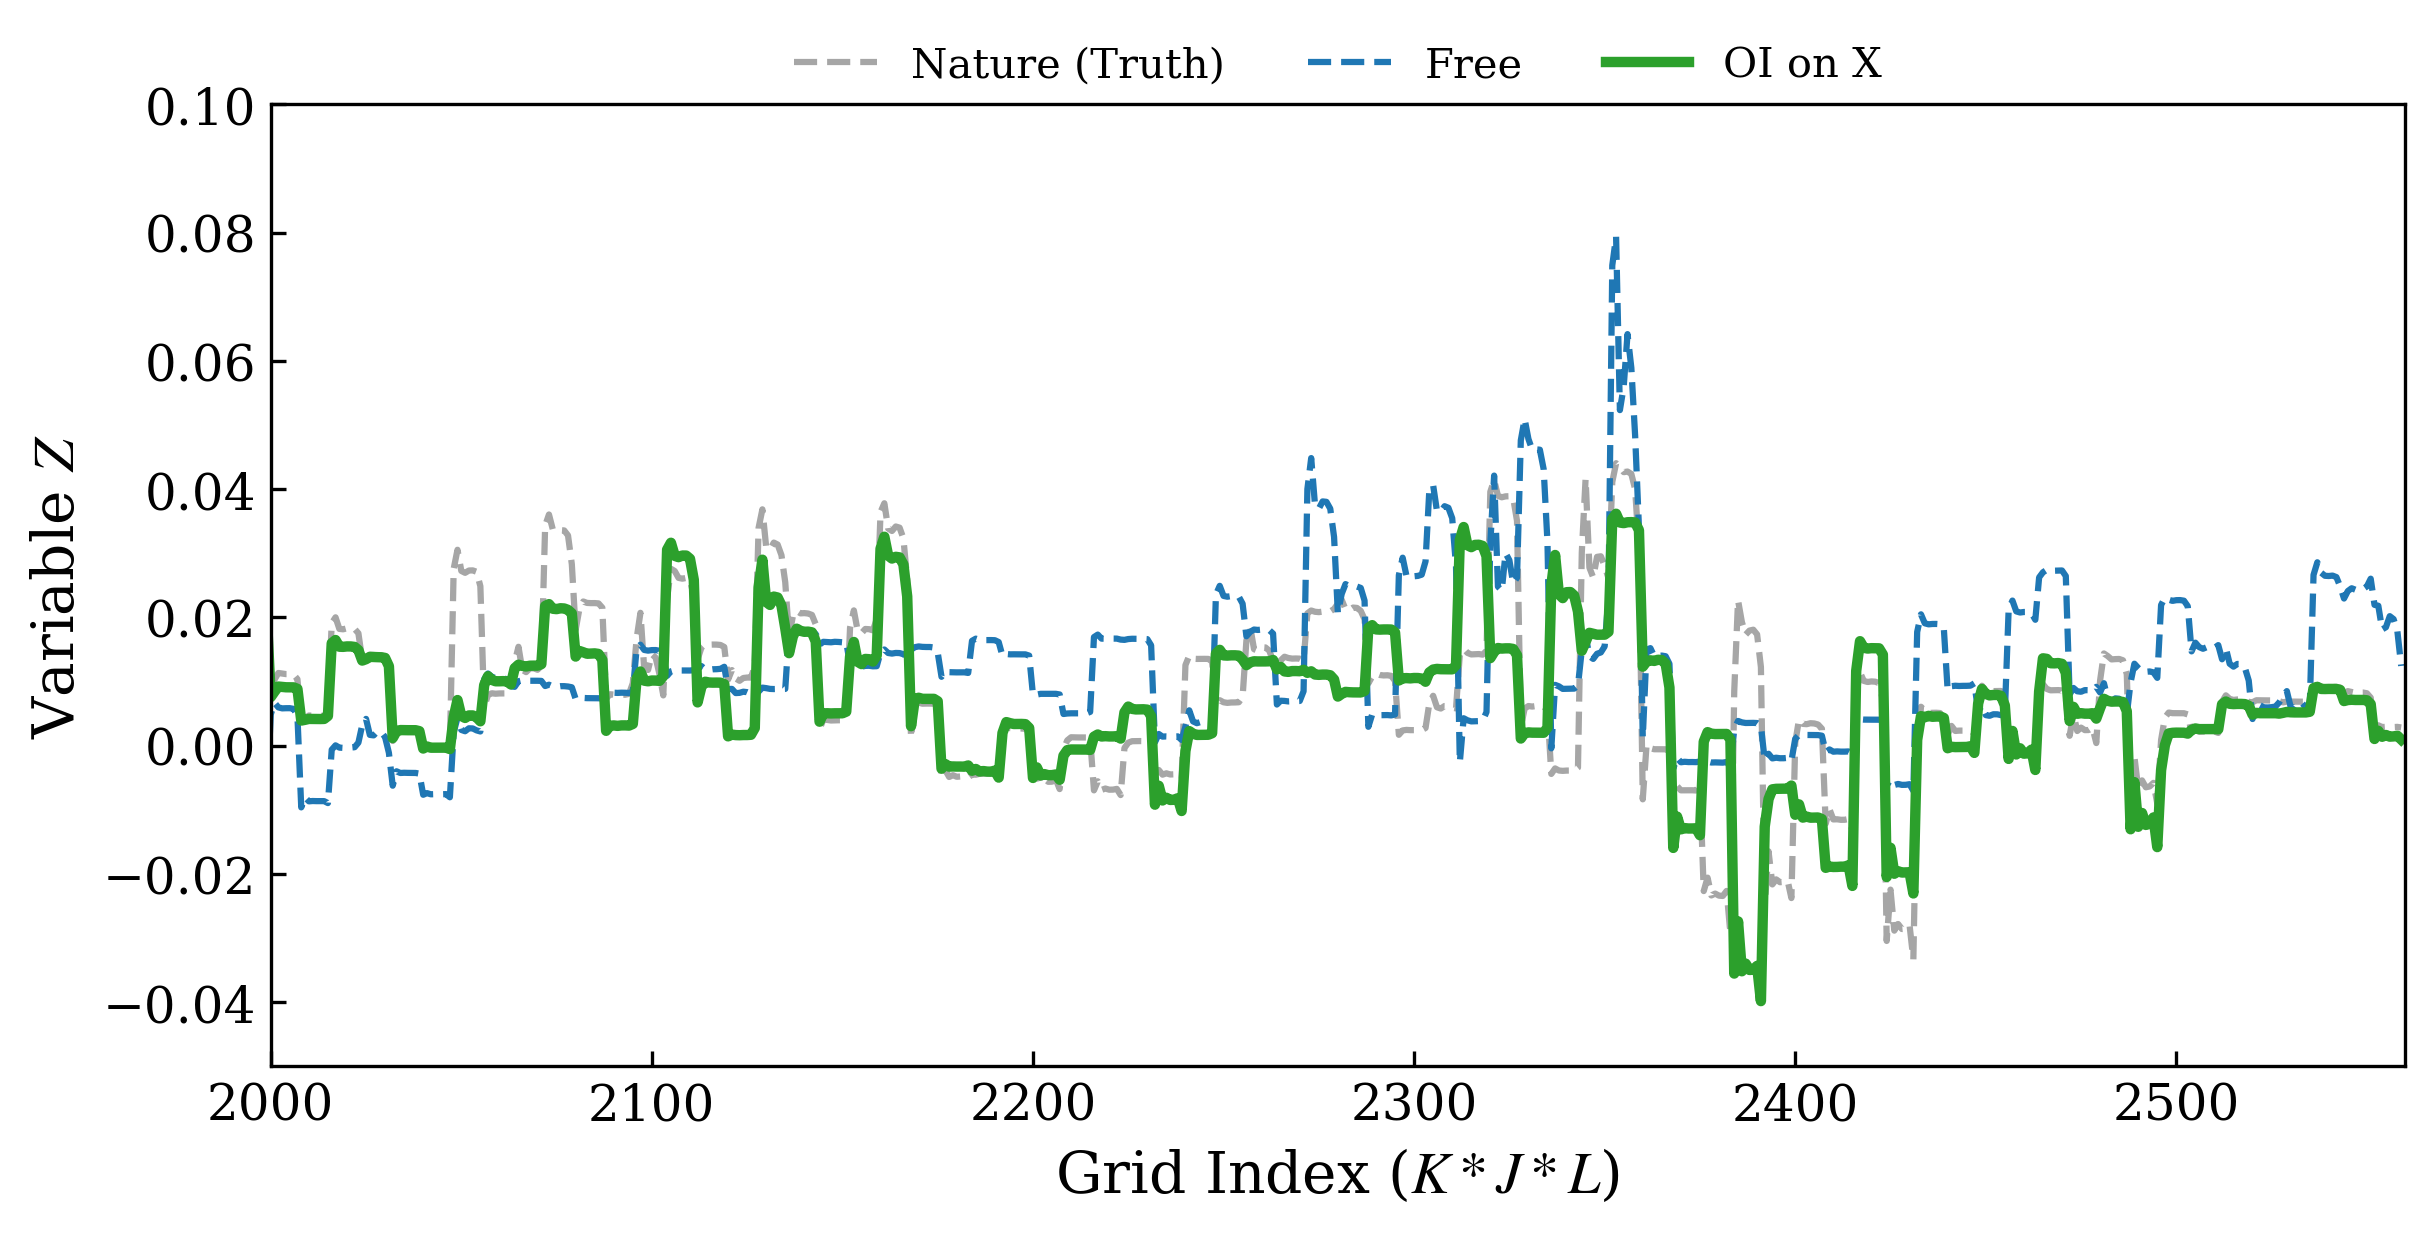

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.plot(
    np.arange(2560), nature_run["Z"][-1].flatten(),
    linestyle="--", label="Nature (Truth)", color="gray", alpha=0.7
)

ax.plot(
    np.arange(2560), free_run["Z"][-1].flatten(),
    linestyle="--", label="Free", color="tab:blue"
)

ax.plot(
    np.arange(2560), OI_run["Z"][-1].flatten(),
    linestyle="-", linewidth=2.5, label=r"OI on X", color="tab:green"
)

ax.set_xlim(2000, 2560)
ax.set_ylim(-0.05, 0.1)

ax.set_xlabel(r"Grid Index ($K*J*L$)")
ax.set_ylabel(r"Variable $Z$")

ax.legend(ncol=4, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.1))

plt.savefig(fig_path / "grid" / "Z_different.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)